In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


from kineticanalysis.generator.generator_track import (generate_tracks, generate_one_track)
from kineticanalysis.analysis.analysis_track import single_track_analysis, check_track_validity

In [2]:
path_save = "/home/u2175049/Documents/Code/KineticAnalysis/notebook/figures/"
path = "/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/01-TrackLength/"

In [3]:
prot_aa_size = {
    "32xsuntag": 796,  #768/32=24 , left 28
    "linker": 4,
    "twist": 490,
    "ilp4": 134,
    "snail": 390,
    "very_long_prot":1200, 
}

In [4]:
# combine track

def combine_2_track(y1, y2) :
    
    y1_norm = y1/np.mean(y1)
    y2_norm = y2/np.mean(y2)
    y_concat = np.concatenate([y1_norm, y2_norm])
    return y_concat

def combine_n_tracks(list_track = []):
    if len(list_track) == 0 :
        return None

    y_concat = np.empty(shape=[0])
    i=0
    for l in list_track:
        # print("----------------------")
        # print(l)
        if i == 0:
            y_concat = np.concatenate([y_concat, l])
            i+=1
        else:
            last_val = y_concat[-1]
            diff_ = last_val - l[0]
            
            # print((l+diff_)[1:])
            y_concat = np.concatenate([y_concat, (l+diff_)[1:]])

    return y_concat



In [5]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
elongation_rate = 5
for i in range(500):
    x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["very_long_prot"], 
                                                      suntag_length = prot_aa_size["32xsuntag"], 
                                                      nb_suntag=32, 
                                                      fluo_one_suntag=4, 
                                                      translation_rate=elongation_rate, 
                                                      binding_rate=0.05,
                                                      step = 0.1,
                                                      length=85000, 
                                                       remove_point_beginning=10000)
    if i == 0:
        datas = pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })
    else:
        datas = pd.concat([datas, 
                           pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })], ignore_index=True)

datas.to_csv(os.path.join(path, "datas_track_length_translation_rate_5.csv"))

In [6]:
# datas = pd.read_csv(os.path.join(path, "datas_track_length.csv"), index_col="Unnamed: 0")
datas

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
0,0.0,1641.326633,0
1,0.1,1641.809045,0
2,0.2,1642.291457,0
3,0.3,1642.773869,0
4,0.4,1643.256281,0
...,...,...,...
419999995,83999.5,2000.884422,499
419999996,83999.6,2001.366834,499
419999997,83999.7,2001.849246,499
419999998,83999.8,2002.331658,499


In [45]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
first = True

for t in [30]:
# t = 50

    dt = t*0.1
    for length_track in [60]:
        print(length_track)
        
        for i in range(500):
            datas2 = datas[datas["TRACK_ID"]==i][::t][:length_track]
            datas2["FRAME"] = np.arange(length_track)
            if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 1) & (len(datas2) in [60]):
                
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                
                (x_auto, 
                 y_auto, 
                 k, c,
                 elongation_r, 
                 translation_init_r,
                 perr) = single_track_analysis(x, 
                                             y, 
                                             delta_t = dt,
                                             protein_size=prot_aa_size["very_long_prot"],
                                             suntag_size =prot_aa_size["32xsuntag"], 
                                             repetition_suntag = 32,
                                             mm=None,
                                             method="exact",
                                             simulation=True)
                if first:
                    results = pd.DataFrame({"elongation_r":elongation_r, 
                                            "init_translation_r":translation_init_r, 
                                            "dt":dt,
                                            "long_track":datas2.shape[0],
                                            "k":k,
                                            "c":c,
                                           "id":i},
                                          index=[0])
                    first = False
                
                else:
                    results = pd.concat([results, 
                                    pd.DataFrame({"elongation_r":elongation_r, 
                                                  "init_translation_r":translation_init_r, 
                                                  "dt":dt, 
                                                  "long_track":datas2.shape[0],
                                                  "k":k,
                                                    "c":c,
                                                  "id":i}, index=[0])
                                    ], ignore_index=True)
                        
results.to_csv(os.path.join(path, "results_dt_track_length_translation_rate_5.csv"))

60
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
50 32
5

In [58]:
nb_combine = 5
for nb_combine in [2, 5, 8, 10, 15, 20, 25, 30]:
    for t in [30]:
    # t = 50
    
        dt = t*0.1
        for length_track in [60]:
            print(length_track)
            
            for i in range(50):
                i*=10
                l_track = [datas[datas["TRACK_ID"]==i][::t][:length_track]["MEAN_INTENSITY_CH1"].to_numpy()]
                for j in range (nb_combine):
                    pos = i+j
                    if pos>=10:
                        pos-=10
                        
                    l_track.append(datas[datas["TRACK_ID"]==pos][::t][:length_track]["MEAN_INTENSITY_CH1"].to_numpy())
    
                y_combined = combine_n_tracks(l_track)
                datas2 = pd.DataFrame({"TRACK_ID":i, 
                                      "MEAN_INTENSITY_CH1": y_combined,
                                      "FRAME": np.arange(len(y_combined))})
                
                # datas2 = datas[datas["TRACK_ID"]==i][::t][:length_track]
                # datas2["FRAME"] = np.arange(length_track)
    
                # fig, ax = plt.subplots()
                # cpt = 0
                # ax.plot(datas2["MEAN_INTENSITY_CH1"], '--', alpha=0.5, color="black")
                # for l in l_track:
                #     ax.plot(np.arange(len(l))+cpt, l)
                #     cpt += len(l)
                    
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                
                (x_auto, 
                 y_auto, 
                 k, c,
                 elongation_r, 
                 translation_init_r,
                 perr) = single_track_analysis(x, 
                                             y, 
                                             delta_t = dt,
                                             protein_size=prot_aa_size["very_long_prot"],
                                             suntag_size =prot_aa_size["32xsuntag"], 
                                             repetition_suntag = 32,
                                             mm=None,
                                             method="exact",
                                             simulation=True)
                
    
                results = pd.concat([results, 
                                pd.DataFrame({"elongation_r":elongation_r, 
                                              "init_translation_r":translation_init_r, 
                                              "dt":dt, 
                                              "long_track":datas2.shape[0],
                                              "k":k,
                                                "c":c,
                                              "id":100+i}, index=[0])
                                ], ignore_index=True)
                        
results.to_csv(os.path.join(path, "results_dt_track_length_translation_rate_5.csv"))

60
50 32
Sorry, due to the complexity of the equation, there is a chance that M or N are too big, and the number are too large to be processed now (cause of factorial).
The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on parameters where applicable. In cases like this, using "nan_policy='omit'" will probably not work.
50 32
Sorry, due to the complexity of the equation, there is a chance that M or N are too big, and the number are too large to be processed now (cause of factorial).
The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on parameters where applicable. In cases like this, using "nan_policy='omit'" will probably not work.
50 32
Sorry, due to the complexity of the equation, there is a chance that M or N are too big, and the number are too large to be processed now (cause of factorial).
The model function generated NaN values and the fit aborted! Pl

In [47]:
# results = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_24.csv"), index_col="Unnamed: 0")

In [59]:
results.groupby(by=['dt', 'long_track'])[['elongation_r','init_translation_r', 'k', 'c']].mean()

elongation_r  init_translation_r         k         c
dt  long_track                                                      
3.0 60             46.207655            8.954027  1.857594  8.954027
    178            15.784278            0.833168  0.634544  0.833168
    355             7.836775            0.183397  0.315046  0.183397
    532             5.514018            0.082354  0.221669  0.082354
    650             4.957629            0.067299  0.199302  0.067299
    945             3.723774            0.047797  0.149699  0.047797
    1240            2.770830            0.021453  0.111390  0.021453
    1535            2.108373            0.015098  0.084759  0.015098
    1830            1.896930            0.013715  0.076258  0.013715

In [55]:
results.groupby(by=['dt', 'long_track'])[['elongation_r','init_translation_r', 'k', 'c']].std()

elongation_r  init_translation_r         k          c
dt  long_track                                                       
3.0 60             23.671280           13.474971  0.951609  13.474971
    178             7.365921            1.276756  0.296117   1.276756
    355             4.006411            0.253072  0.161062   0.253072
    532             2.446710            0.102138  0.098360   0.102138
    650             2.873662            0.103202  0.115524   0.103202
    945             2.394478            0.098232  0.096260   0.098232
    1240            1.513845            0.021305  0.060858   0.021305

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


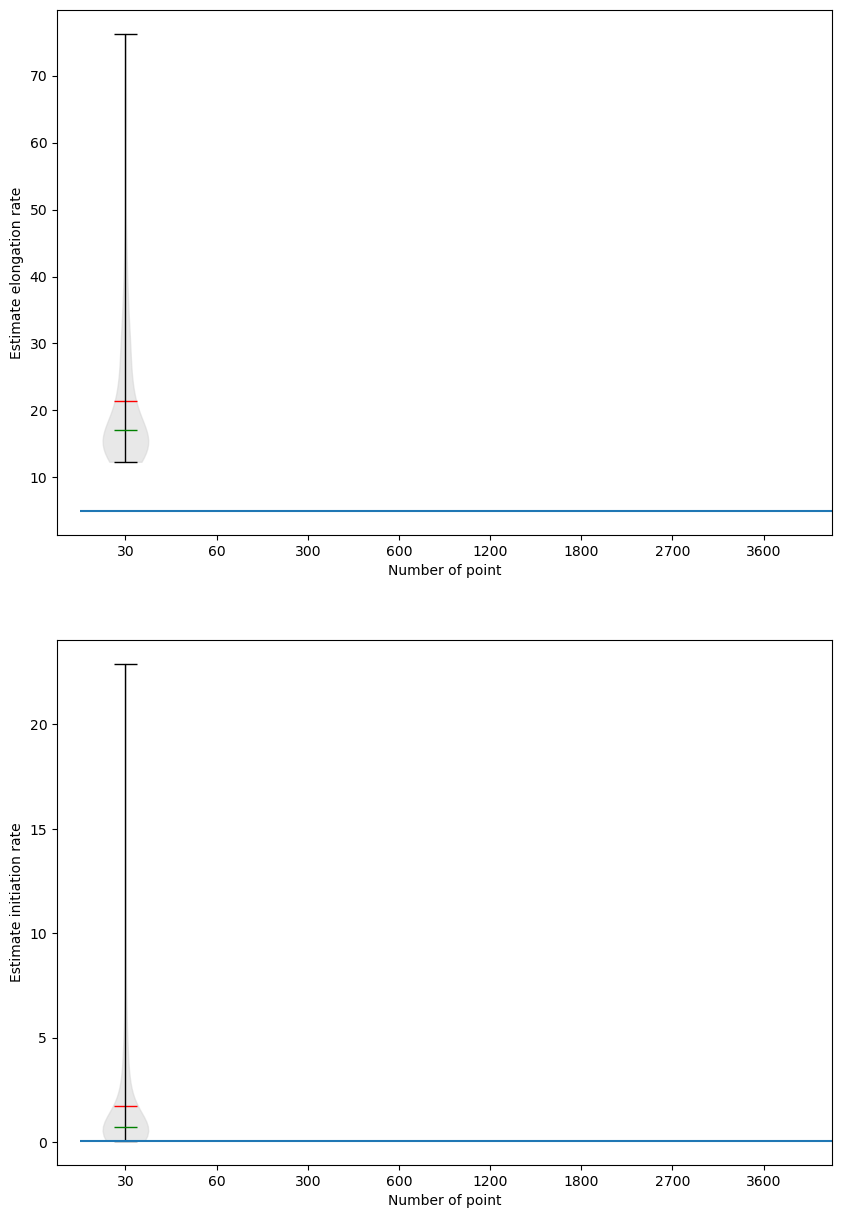

In [15]:
fig, ax = plt.subplots(2,1)


violin = ax[0].violinplot(dataset = [results[ (results.long_track == length_track)]["elongation_r"].values for length_track in [120,1310]],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1
# results.boxplot(['init_translation_r'] , 
#                by=['dt', "long_track"], 
#                grid=False, 
#                ax = ax[1],
#                rot=90,
#                boxprops=dict(linestyle='-', linewidth=1.5, color="black"),
#                medianprops=dict(linestyle='-', linewidth=1.5, color="red"),
#                )


violin = ax[1].violinplot(dataset = [results[(results.long_track == length_track)]["init_translation_r"].values for length_track in [120,1310]],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1

group = ['dt', "long_track"]
column = 'elongation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[0].scatter(x, val, c='grey', alpha=1, s=10)
    
group = ['dt', "long_track"]
column = 'init_translation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[1].scatter(x, val, c='grey', alpha=1, s=20)

def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Number of point')
# set style for the axes
labels =[30,60,300,600,1200,1800,2700,3600]
for a in ax:
    set_axis_style(a, labels)

ax[0].set_ylabel("Estimate elongation rate")
ax[1].set_ylabel("Estimate initiation rate")

# ax[0].set_ylim(-5,50)
# ax[1].set_ylim(-1, 20)
ax[0].hlines(elongation_rate, 0.5, 9.5)
ax[1].hlines(0.05, 0.5, 9.5)
fig.set_size_inches((10,15))
fig.savefig(os.path.join(path_save, "results_length_boxplot_exact_dt1_0.05_5.eps"), dpi=300)

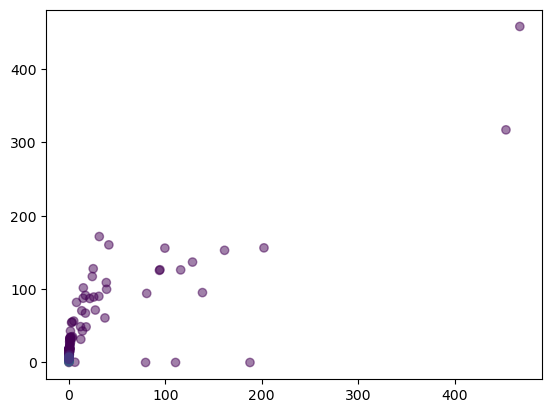

In [44]:
fig, ax = plt.subplots()
ax.scatter(results["init_translation_r"], results["elongation_r"], c=results["long_track"], alpha=0.5)
# ax.set_xlim(0,50)
# ax.set_ylim(0,50)

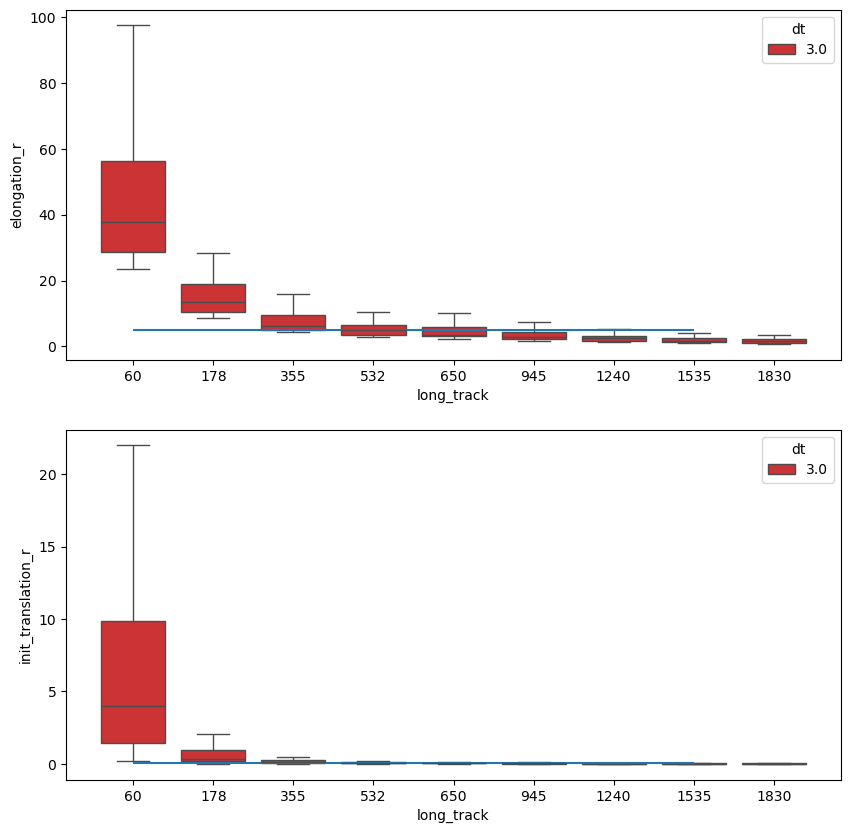

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [60]:
import seaborn as sns

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="long_track", y="elongation_r", hue="dt", data=results, palette="Set1", showfliers=False, ax = axes[0])
# axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 7)

sns.boxplot(x="long_track", y="init_translation_r", hue="dt", data=results, palette="Set1", showfliers=False, ax = axes[1])
# axes[1].set_ylim(-0.2, 1)
axes[1].hlines(0.05, 0.0, 7)

fig.set_size_inches(10,10)
plt.show()
fig.savefig(os.path.join(path_save, "track_length_dt_combined.eps"), dpi=300)

In [ ]:
results[(results.dt == 60.0) & (results.long_track >1000) & (results.elongation_r>0)]

In [ ]:
results_group = results.groupby(["dt", "long_track"]).mean()
results_group.reset_index(inplace=True)

elongation_ref = 24

results_group["elongation_r_diff"] = elongation_ref-results_group['elongation_r']
results_group["elongation_r_ratio"] = 100*results_group["elongation_r"]/elongation_ref - 100
results_group["elongation_r_ratio"]= np.abs(results_group["elongation_r_ratio"])


results_group["init_translation_r_diff"] = 20-results_group['init_translation_r']
results_group["init_translation_r_ratio"] = 100*results_group["init_translation_r"]/20 -100
results_group["init_translation_r_ratio"] = np.abs(results_group["init_translation_r_ratio"])

results_group

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='elongation_r_ratio')

# Create the heatmap
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))
# plt.figure(figsize=(8, 6))
ax1 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100,
                 ax=ax1)
# Invert the y-axis
ax1.invert_yaxis()
ax1.set_title("Heatmap of elongation rate Values")
ax1.set_xlabel("time step")
ax1.set_ylabel("track length")



heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')
ax2 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100, 
                  ax = ax2
                )
# Invert the y-axis
ax2.invert_yaxis()
ax2.set_title("Heatmap of initiation rate Values")
ax2.set_xlabel("time step")
ax2.set_ylabel("track length")

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap=combined_colors,
                 vmin = 0,
                 vmax = 200
                )
# Invert the y-axis
ax.invert_yaxis()

plt.title("Heatmap of initiation rate Values")
plt.xlabel("time step")
plt.ylabel("track length")
plt.show()